In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import openpyxl

# Cargar datos
df = pd.read_csv('../data/construction_cost_dataset_pro.csv')
df = pd.read_excel('../data/dataset_costos_pro_multitabla.xlsx')



# Config estilo
plt.style.use('ggplot')

# Formato de dinero (miles de millones)
def format_billions(x, pos):
    return f'${x/1e9:.1f}B'

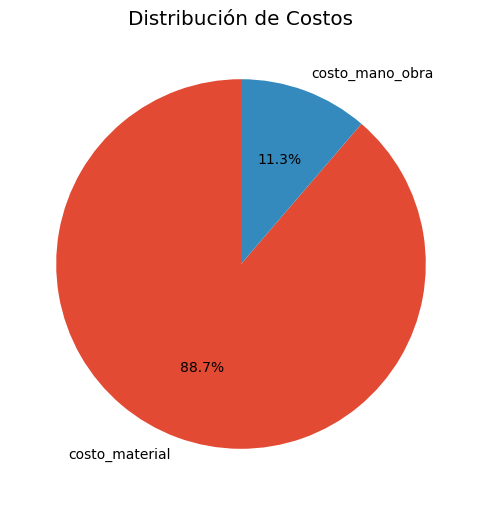

In [3]:
costos = df[['costo_material','costo_mano_obra']].sum()

fig, ax = plt.subplots(figsize=(6,6))
costos.plot(kind='pie', autopct='%1.1f%%', startangle=90)

plt.title("Distribución de Costos")
plt.ylabel('')
plt.show()

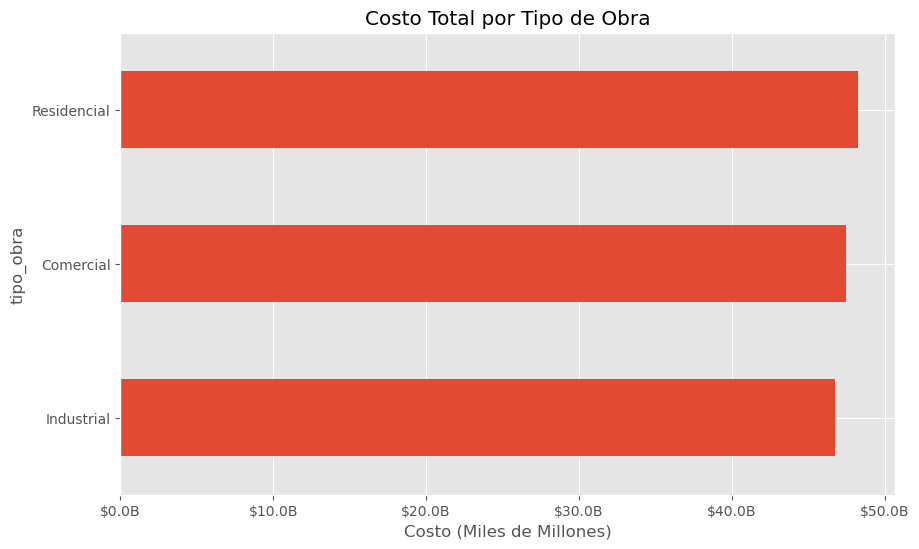

In [4]:
costos_tipo = df.groupby('tipo_obra')['costo_real'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10,6))
costos_tipo.plot(kind='barh')

ax.set_title("Costo Total por Tipo de Obra")
ax.xaxis.set_major_formatter(plt.FuncFormatter(format_billions))

plt.xlabel("Costo (Miles de Millones)")
plt.show()

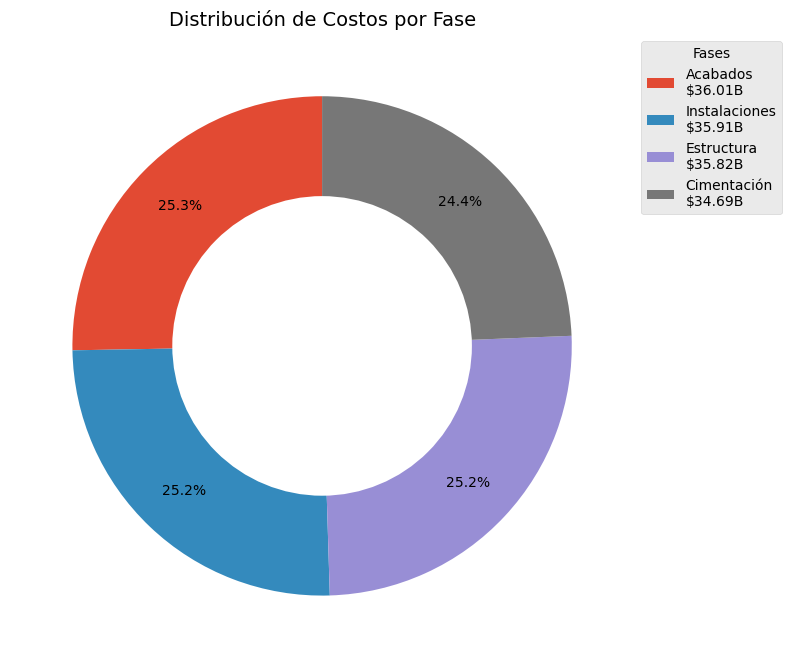

In [7]:
fase_costos = df.groupby('fase')['costo_real'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,8))

# 🔹 SIN definir colores → usa los originales
wedges, texts, autotexts = ax.pie(
    fase_costos,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8
)

# Donut
centre_circle = plt.Circle((0,0),0.60,fc='white')
fig.gca().add_artist(centre_circle)

# 🔹 Leyenda con valores reales
labels_legend = [
    f"{fase}\n${valor/1e9:.2f}B"
    for fase, valor in zip(fase_costos.index, fase_costos.values)
]

ax.legend(
    wedges,
    labels_legend,
    title="Fases",
    loc="upper left",
    bbox_to_anchor=(1, 1)
)

plt.title("Distribución de Costos por Fase", fontsize=14)

plt.tight_layout()
plt.show()

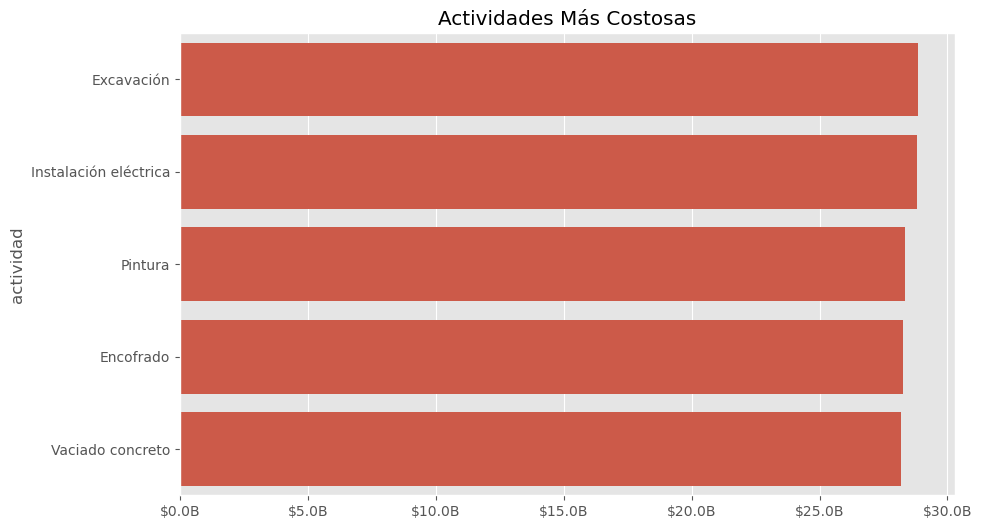

In [10]:
top_actividades = df.groupby('actividad')['costo_real'].sum().nlargest(10)

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=top_actividades.values, y=top_actividades.index)

ax.xaxis.set_major_formatter(plt.FuncFormatter(format_billions))
plt.title("Actividades Más Costosas")

plt.show()

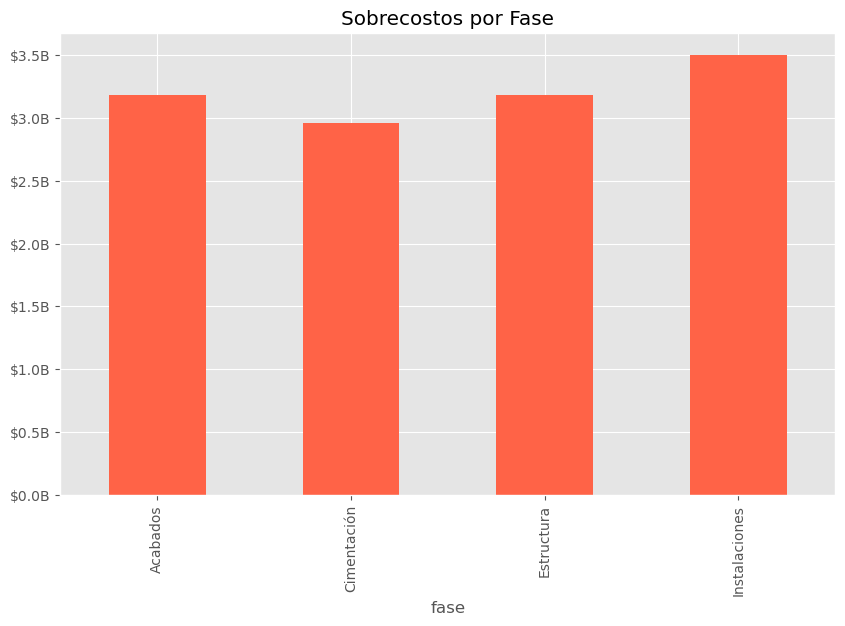

In [9]:
sobrecostos = df.groupby('fase')['diferencia_costo'].sum()

fig, ax = plt.subplots(figsize=(10,6))
sobrecostos.plot(kind='bar', color='tomato')

plt.title("Sobrecostos por Fase")
ax.yaxis.set_major_formatter(plt.FuncFormatter(format_billions))

plt.show()

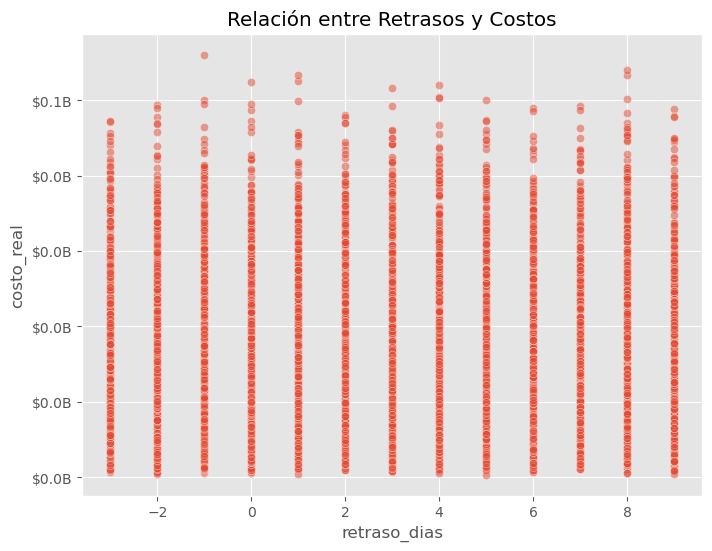

In [11]:
fig, ax = plt.subplots(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='retraso_dias',
    y='costo_real',
    alpha=0.5
)

ax.yaxis.set_major_formatter(plt.FuncFormatter(format_billions))
plt.title("Relación entre Retrasos y Costos")

plt.show()

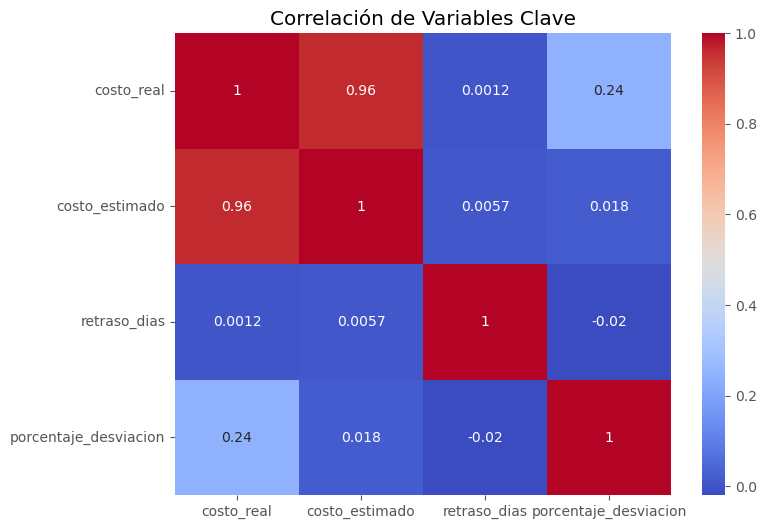

In [12]:
corr = df[['costo_real','costo_estimado','retraso_dias','porcentaje_desviacion']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlación de Variables Clave")
plt.show()

In [13]:
kpis = {
    "Costo Total": df['costo_real'].sum(),
    "Costo Promedio Proyecto": df.groupby('proyecto')['costo_real'].sum().mean(),
    "Desviación Promedio (%)": df['porcentaje_desviacion'].mean(),
    "Total Sobrecostos": df[df['diferencia_costo'] > 0]['diferencia_costo'].sum()
}

kpis

{'Costo Total': np.int64(142425840727),
 'Costo Promedio Proyecto': np.float64(7121292036.35),
 'Desviación Promedio (%)': np.float64(9.690985418266786),
 'Total Sobrecostos': np.int64(17229538827)}

In [14]:
rfm = df.groupby('proyecto').agg({
    'costo_real':'sum',
    'retraso_dias':'mean',
    'porcentaje_desviacion':'mean'
})

rfm.columns = ['Costo','Retraso','Desviacion']

# Segmentación simple
rfm['Segmento'] = pd.qcut(rfm['Costo'], 3, labels=['Bajo','Medio','Alto'])

rfm.head()

,Costo,Retraso,Desviacion,Segmento
proyecto,,,,
Proyecto_1,6637715370,2.971983,10.110255,Bajo
Proyecto_10,6560112166,3.419223,9.866009,Bajo
Proyecto_11,7852999406,3.215264,9.343909,Alto
Proyecto_12,7251199720,3.050485,10.133395,Alto
Proyecto_13,8005815775,3.069982,10.361027,Alto


🧾 4. RECOMENDACIONES 

📌 Control de costos
Implementar seguimiento en tiempo real de materiales
Negociar proveedores clave
📌 Gestión de proyectos
Control en fases con mayor sobrecosto
Planificación en cimentación y acabados
📌 Operación
Reducir retrasos → impacto directo en costos
Mejorar asignación de mano de obra

In [8]:
import pandas as pd
import numpy as np

# 🔹 Cargar archivos
df_act = pd.read_excel('../data/dataset_costos_pro_multitabla.xlsx', sheet_name='actividades')
df_mat = pd.read_excel('../data/dataset_costos_pro_multitabla.xlsx', sheet_name='materiales')
df_base = pd.read_csv('../data/construction_cost_dataset_pro.csv')

# 🔹 Unir modelo relacional
df = df_act.merge(df_mat, on='actividad_id', how='left')

# 🔹 Calcular costos
df['costo_material'] = df['cantidad'] * df['costo_unitario']
df['costo_real'] = df['costo_mano_obra'] + df['costo_material']

# 🔹 Costo estimado (simulación realista)
df['costo_estimado'] = df['costo_real'] * np.random.uniform(0.9, 1.1, len(df))

# 🔹 Completar columnas faltantes del dataset original
for col in df_base.columns:
    if col not in df.columns:
        if col == 'ciudad':
            df[col] = 'Bogotá'
        else:
            df[col] = None

# 🔹 Ordenar columnas igual que dataset original
df = df[df_base.columns]

# 🔹 Guardar archivo final
df.to_csv('dataset_costos_constructivos_final.csv', index=False)

print("✅ Dataset final generado correctamente")

✅ Dataset final generado correctamente


In [3]:
import os
print(os.getcwd())

/home/jhanph/Analisis_Costos_Constructivos_JHconstrucciones/notebooks


In [4]:
import os
print(os.listdir())

['analisis_costos2.ipynb', 'analisis_costos.ipynb']


In [7]:
import os
print(os.listdir('../data'))

['dataset_costos_pro_multitabla.xlsx', 'construction_cost_dataset_pro.csv']
